In [255]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
# Regression
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
# Classifiction
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MaxAbsScaler

from keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

import nltk as k
from nltk.tokenize import word_tokenize as wt
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import re
import string as s


### read or import data

In [218]:
data = pd.read_csv(R'C:\Users\G.B\Desktop\osam\المرحلة الثانية\data science\NLP\spam.csv')

In [219]:
data.head()

,v1,v2
0,"ham,""Go until jurong point, crazy.. Available ...",NaN
1,ham,Ok lar… then Joking wif u oni…
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,"ham,""Nah I don't think he goes to usf, he live...",NaN


### get som information about data

In [220]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      523 non-null    object
 1   v2      384 non-null    object
dtypes: object(2)
memory usage: 8.3+ KB


In [221]:
data.isnull().sum()

v1      0
v2    139
dtype: int64

<Axes: >

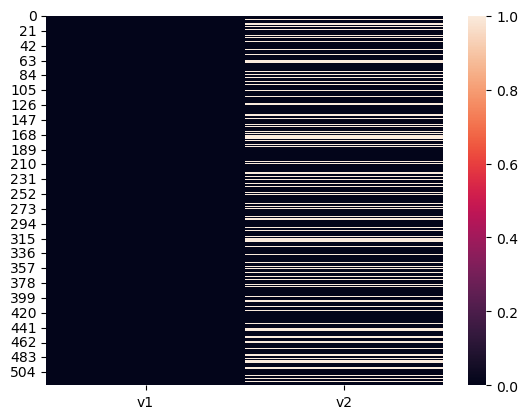

In [222]:
sns.heatmap(data.isnull())

In [223]:
data.describe()

,v1,v2
count,523,384
unique,137,380
top,ham,As per your request 'Melle Melle (Oru Minnamin...
freq,336,3


In [224]:
data.columns

Index(['v1', 'v2'], dtype='object')

In [225]:
data.duplicated().sum()

8

In [134]:
data['Spam'].unique()

KeyError: 'Spam'

### Data processing

In [233]:
data.columns =['text','stat']

In [230]:
data = data[['stat','text']]

In [12]:
data.dropna(['name'],axis=1)

TypeError: DataFrame.dropna() takes 1 positional argument but 2 positional arguments (and 1 keyword-only argument) were given

In [231]:
data = data.dropna()

In [234]:
data.head()

,text,stat
1,Ok lar… then Joking wif u oni…,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
6,Even my brother is not like to speak with me. ...,ham
7,As per your request 'Melle Melle (Oru Minnamin...,ham


In [235]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 1 to 521
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    384 non-null    object
 1   stat    384 non-null    object
dtypes: object(2)
memory usage: 9.0+ KB


### Data NLP

In [236]:
k.download('stopwords')# wordnet
k.download('wordnet') # for lemmtizing
k.download('punkt') # for word_tokenize

[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

In [237]:
lem =k.wordnet.WordNetLemmatizer()
po =k.porter.PorterStemmer()

In [238]:
stop_word =k.corpus.stopwords.words('english')

In [239]:
def nlp(data):
    rem_punc=''.join([char for char in data if char not in s.punctuation])
    tokn = re.split('\W',rem_punc)
    # tok = wt(text) but it need net
    lemmat=' '.join([lem.lemmatize(char) for char in tokn if char not in stop_word])
    return lemmat
data['clean_text']=data['text'].apply(lambda x: nlp(x)) 

In [240]:
data.head()

,text,stat,clean_text
1,Ok lar… then Joking wif u oni…,ham,Ok lar Joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Free entry 2 wkly comp win FA Cup final tkts 2...
3,U dun say so early hor... U c already then say...,ham,U dun say early hor U c already say
6,Even my brother is not like to speak with me. ...,ham,Even brother like speak They treat like aid pa...
7,As per your request 'Melle Melle (Oru Minnamin...,ham,As per request Melle Melle Oru Minnaminunginte...


In [241]:
def nlp(data):
    sm=[]
    for i in data:
        if i ==1:
            sm.append("verygood")
        elif i ==0:
            sm.append("good")
        else:
            sm.append("bad")
    return sm
data['sm_hm'] =nlp(data['stat'])
#data['sm_hm']=data['stat'].apply(lambda x: nlp(x)) 

In [242]:
data.head()

,text,stat,clean_text,sm_hm
1,Ok lar… then Joking wif u oni…,ham,Ok lar Joking wif u oni,bad
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Free entry 2 wkly comp win FA Cup final tkts 2...,bad
3,U dun say so early hor... U c already then say...,ham,U dun say early hor U c already say,bad
6,Even my brother is not like to speak with me. ...,ham,Even brother like speak They treat like aid pa...,bad
7,As per your request 'Melle Melle (Oru Minnamin...,ham,As per request Melle Melle Oru Minnaminunginte...,bad


In [243]:
vectcoun = CountVectorizer()
ngram =CountVectorizer(ngram_range=(1,2)) # style for ngram
tf =TfidfVectorizer(ngram_range=(1,3)) # style for ngram

In [244]:
feature_cv = vectcoun.fit_transform(data['clean_text'])
ngram_fit = ngram.fit_transform(data["clean_text"])
tf_fit = tf.fit_transform(data["clean_text"])

In [ ]:
tf =TfidfVectorizer(ngram_range=(1,3)) # style for ngram
tf_fit = tf.fit_transform(data["clean_text"])
tf_fit1 =pd.DataFrame(tf_fit.toarray())
tf_fit1.columns = tf.get_feature_names_out()

In [245]:
feature_cv =pd.DataFrame(feature_cv.toarray())
feature_cv.columns = vectcoun.get_feature_names_out()

ngram_fit =pd.DataFrame(ngram_fit.toarray())
ngram_fit.columns = ngram.get_feature_names_out()

tf_fit1 =pd.DataFrame(tf_fit.toarray())
tf_fit1.columns = tf.get_feature_names_out()

In [246]:
feature_cv

,0125698789,021,07046744435,07123456789,07732584351,07742676969,0800,08000930705,08000938767,08002986030,...,youll,your,youre,youve,youwhen,yr,yummy,yup,جll,جد
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0,0,0,0,0,0,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
380,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [247]:
ngram_fit

,0125698789,0125698789 ring,021,021 3680offer,07046744435,07046744435 arrange,07123456789,07123456789 87077,07732584351,07732584351 rodger,...,yup how,yup lunch,yup next,yup ok,yup thk,جll,جll finish,جد,جد predict,جد say
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
380,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
381,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [248]:
tf_fit1

,0125698789,0125698789 ring,0125698789 ring me,021,021 3680offer,021 3680offer end,07046744435,07046744435 arrange,07046744435 arrange delivery,07123456789,...,yup thk,yup thk cine,جll,جll finish,جll finish buying,جد,جد predict,جد predict wat,جد say,جد say like
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
380,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
381,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
382,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [249]:
import string as s

In [250]:
data.head()

,text,stat,clean_text,sm_hm
1,Ok lar… then Joking wif u oni…,ham,Ok lar Joking wif u oni,bad
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Free entry 2 wkly comp win FA Cup final tkts 2...,bad
3,U dun say so early hor... U c already then say...,ham,U dun say early hor U c already say,bad
6,Even my brother is not like to speak with me. ...,ham,Even brother like speak They treat like aid pa...,bad
7,As per your request 'Melle Melle (Oru Minnamin...,ham,As per request Melle Melle Oru Minnaminunginte...,bad


In [251]:
def count_per(text):
    count = sum([1 for char in text if char in s.punctuation])
    return round( count/(len(text)-text.count(' ')),1)*100

data['punct'] = data['text'].apply(lambda x: count_per(x))

def count_cap(text):
    count = sum([1 for char in text if char.isupper()])
    return round( count/(len(text)-text.count(' ')),1)*100

data['cap'] = data['text'].apply(lambda x: count_cap(x))


In [258]:
data['text_len'] =data['text'].apply(lambda x: len(x)-x.count(' '))

In [259]:
data.head()

,text,stat,clean_text,punct,cap,text_len
1,Ok lar… then Joking wif u oni…,ham,Ok lar Joking wif u oni,0.0,10.0,24
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Free entry 2 wkly comp win FA Cup final tkts 2...,0.0,10.0,128
3,U dun say so early hor... U c already then say...,ham,U dun say early hor U c already say,20.0,10.0,39
6,Even my brother is not like to speak with me. ...,ham,Even brother like speak They treat like aid pa...,0.0,0.0,62
7,As per your request 'Melle Melle (Oru Minnamin...,ham,As per request Melle Melle Oru Minnaminunginte...,0.0,10.0,135


In [260]:
scaler = MaxAbsScaler()
num_var =['text_len','punct','cap']
data[num_var] = scaler.fit_transform(data[num_var]) # back the value to 0.2554

In [261]:
data.head()

,text,stat,clean_text,punct,cap,text_len
1,Ok lar… then Joking wif u oni…,ham,Ok lar Joking wif u oni,0.0,0.1,0.126316
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam,Free entry 2 wkly comp win FA Cup final tkts 2...,0.0,0.1,0.673684
3,U dun say so early hor... U c already then say...,ham,U dun say early hor U c already say,0.4,0.1,0.205263
6,Even my brother is not like to speak with me. ...,ham,Even brother like speak They treat like aid pa...,0.0,0.0,0.326316
7,As per your request 'Melle Melle (Oru Minnamin...,ham,As per request Melle Melle Oru Minnaminunginte...,0.0,0.1,0.710526


In [283]:
x=data.drop(['text','clean_text'],axis=1)
x = pd.concat([x,pd.DataFrame(tf_fit1)],axis=1)
x =x.dropna()
y = x['stat']
x = x.drop(['stat'],axis=1)

In [289]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.25,random_state=40)

In [290]:
model = RandomForestClassifier(n_jobs=-1,n_estimators=10)

In [291]:
model.fit(xtrain, ytrain)

RandomForestClassifier(n_estimators=10, n_jobs=-1)

In [293]:
model.score(xtrain,ytrain)

0.9428571428571428

In [294]:
model.score(xtest,ytest)

0.8625592417061612

In [295]:
sorted(zip(model.feature_importances_, xtrain.columns), reverse=True)[0:10]
# have import feature input in the data

[(0.08648203047797362, 'spoil bed well'),
 (0.0693834251706799, 'thuglyfe falconerf'),
 (0.06449235304956699, 'hold'),
 (0.057961022246736535, 'bed'),
 (0.04111888111888113, 'status'),
 (0.040436554898093356, 'good'),
 (0.03823529411764708, 'deepak 5min'),
 (0.03823529411764708, 'check audreys'),
 (0.030525030525030535, 'please call 07046744435'),
 (0.027662004877898178, 'service annoncement you')]

In [296]:
ypred = model.predict(xtest)

In [297]:
ypred

array(['ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham', 'ham',
       'ham', 'ham',

In [331]:
mass = "Tell me MM"
text = [mass]

In [306]:
text

['Free entry 2 wkly comp win FA Cup final tkts 21st May 2005 Text FA 87121 receive entry questionstd txt rateTCs apply 08452810075over18s']

In [371]:
tf =TfidfVectorizer(ngram_range=(1,3)) # style for ngram

tf_fit = tf.fit_transform(text)

In [374]:
tf_fit.toarray()

array([[0.40824829, 0.40824829, 0.40824829, 0.40824829, 0.40824829,
        0.40824829]])

In [336]:
punct = sum([1 for char in mass if char in s.punctuation])
punct  =round( punct/(len(text)-text.count(' ')),1)*100

In [337]:
punct

0.0

In [334]:
count = sum([1 for char in mass if char.isupper()])

In [335]:
count

3

In [345]:
long =len(mass)-mass.count(' ')

In [346]:
long

8

In [376]:
ar= [punct,count,long]

In [355]:
ar =pd.DataFrame(ar)

In [377]:
ar

[0.0, 2, 8]

In [380]:
c = pd.DataFrame(tf_fit,ar)

ValueError: Shape of passed values is (1, 1), indices imply (3, 1)

In [381]:
model.predict([[1,2,3,3,3,3,3,4]])

ValueError: X has 8 features, but RandomForestClassifier is expecting 6616 features as input.

In [367]:
xtest.shape

(211, 6616)